# Postprocessing

In [1]:
import flopy
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from rtmf6.postprocessing.output_reader import ShelveViewer
import numpy as np

In [ ]:
#%% LOAD MODEL
sim_name = 'appelo_uran'
gwf_name = f'gwf_{sim_name}'
gwt_name = f'gwt_{sim_name}'
sim_ws = './mf6'

sim = flopy.mf6.MFSimulation.load(
    sim_name,
    'mf6',
    exe_name='mf6',
    sim_ws=sim_ws
)

gwf = sim.get_model(gwf_name)

mg = gwf.modelgrid
x = mg.xcellcenters
y = mg.ycellcenters

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package npf...
    loading package ic...
    loading package wel...
    loading package chd...
    loading package oc...
  loading model gwt6...
    loading package dis...
    loading package ic...
    loading package ssm...
    loading package adv...
    loading package dsp...
    loading package mst...
    loading package oc...
  loading exchange package gwf-gwt_exg_0...
  loading solution package gwf_appelo_uran...
  loading solution package gwt_appelo_uran...


AttributeError: 'OutputType' object has no attribute 'selected_output_1'

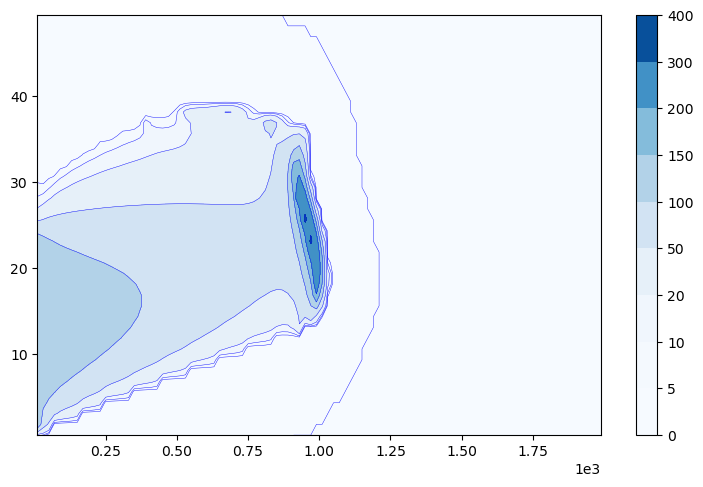

In [ ]:
#%% Plot
viewer = ShelveViewer('rtmf6.toml') ## load from selected output
timestep = 730

pht3d_path ='./pht3d_results'

plt.figure(1,figsize=(20,12))

### U(6)
plt.subplot(2,2,1)

fname = pht3d_path + "/PHT3D009.UCN"
ucnobj = flopy.utils.UcnFile(fname, precision='auto')
times = ucnobj.get_times()
c_pht3d= ucnobj.get_alldata()
ucnobj.close()
ra = [0,5,10,20,50,100,150,200,300,400]
cs=plt.contourf(x,y,c_pht3d[-1,0,:,:]*1e6,ra,cmap='Blues')
plt.colorbar()

csl=plt.contour(x,y,c_pht3d[-1,0,:,:]*1e6,ra,colors='b',linewidths=0.3)


UO2 = viewer.selected_output.selected_output_1.get_value(timestep)['U(6)']

csp=plt.contour(x,y,UO2[0,:,:]*1e6,ra,colors='k',linestyles='dashed')
plt.clabel(csp,fmt='%1.2f')

#plt.streamplot(x, np.flipud(y), qx[0,:,:], qy[0,:,:], density = 0.6,color='k')


# eigene Legendenelemente
legend_lines = [
    Line2D([0], [0], color='b', lw=1, label='PHT3D'),
    Line2D([0], [0], color='k', lw=1, linestyle='--', label='RTMF6')
]

plt.legend(handles=legend_lines, loc=1,fontsize=16)

plt.title('U(6) (umol/L)',fontsize=18)
#plt.xlabel('X (m)',fontsize=16)
plt.ylabel('Z (m)',fontsize=18)
plt.xticks([])
plt.yticks(fontsize=14)

### pH
plt.subplot(2,2,2)
fname = pht3d_path + "/PHT3D011.UCN"
ucnobj = flopy.utils.UcnFile(fname, precision='auto')
times = ucnobj.get_times()
c_pht3d= ucnobj.get_alldata()
ucnobj.close()
ra = np.arange(1.0,9,1.0)

cs=plt.contourf(x,y,c_pht3d[-1,0,:,:],ra,cmap='Blues')
plt.colorbar()

csl=plt.contour(x,y,c_pht3d[-1,0,:,:],ra,colors='b',linewidths=0.3)


pH = viewer.selected_output.selected_output_1.get_value(timestep)['pH']

csp=plt.contour(x,y,pH[0,:,:],ra,colors='k',linestyles='dashed')
plt.clabel(csp,fmt='%1.2f')

plt.title('pH',fontsize=18)
#plt.xlabel('X (m)',fontsize=16)
#plt.ylabel('Y (m)',fontsize=18)
plt.xticks([])
plt.yticks([])


### pE
plt.subplot(2,2,3)
fname = pht3d_path + "/PHT3D012.UCN"
ucnobj = flopy.utils.UcnFile(fname, precision='auto')
times = ucnobj.get_times()
c_pht3d= ucnobj.get_alldata()
ucnobj.close()
ra = np.arange(-3,25,2)

cs=plt.contourf(x,y,c_pht3d[-1,0,:,:],ra,cmap='Blues')
plt.colorbar()

csl=plt.contour(x,y,c_pht3d[-1,0,:,:],ra,colors='b',linewidths=0.3)


pE = viewer.selected_output.selected_output_1.get_value(timestep)['pe']

csp=plt.contour(x,y,pE[0,:,:],ra,colors='k',linestyles='dashed')
plt.clabel(csp,fmt='%1.2f')

plt.title('pE',fontsize=18)
plt.xlabel('X (m)',fontsize=16)
plt.ylabel('Z (m)',fontsize=18)
#plt.xticks([])
#plt.yticks([])


### Coffinite
plt.subplot(2,2,4)
fname = pht3d_path + "/PHT3D013.UCN"
ucnobj = flopy.utils.UcnFile(fname, precision='auto')
times = ucnobj.get_times()
c_pht3d= ucnobj.get_alldata()
ucnobj.close()
ra = np.arange(0,22,2)
cs=plt.contourf(x,y,c_pht3d[-1,0,:,:]*1000,ra,cmap='Blues')
plt.colorbar()

csl=plt.contour(x,y,c_pht3d[-1,0,:,:]*1000,ra,colors='b',linewidths=0.3)


Coffinite = viewer.selected_output.selected_output_1.get_value(timestep)['Coffinite']

csp=plt.contour(x,y,Coffinite[0,:,:]*1000,ra,colors='k',linestyles='dashed')
plt.clabel(csp,fmt='%1.2f')



plt.title('Coffinite (mmol/L_w)',fontsize=18)
plt.xlabel('X (m)',fontsize=16)
#plt.ylabel('Y (m)',fontsize=18)
plt.xticks([])
#plt.yticks([])

plt.tight_layout()



plt.tight_layout()
plt.savefig('../results/PHT3D_RTMF6_compare.png')
